# Random Forests


In this notebook we are using random forests and other similar ensemble methodes in order to predict the state (awake, REM-sleeo, nonREM-sleep) of a mouse based on its electrical brain activity.

> **Do not use Run All in this notebook.** The randomized-search cell would run for a long time and overwrite the teacher's saved results. The three cells marked « This cell is not meant to be executed » must keep their saved outputs: you need them for Q2.1–Q2.7. Run the other cells one by one, and never clear the outputs of these three cells.


In [6]:
#IMPORTS PACKAGES
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [7]:
path = os.path.join(os.getcwd(), 'EEG_mouse_data.csv')
data_mice = pd.read_csv(path)

In [8]:
#CREATE X AND Y FROM DATAFRAME / SPLIT THE DATA INTO TRAIN/TEST
X = data_mice.drop(['EEGv','state'],axis=1).to_numpy()
Y = data_mice['state'].values

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## HYPERPARAMETERS OPTIMIZATION

Many different hyperparameters can be tuned in order to obtain a good random forest classifier. In this example, we will look specifically at the number of trees in the random forest (n_estimators), The number of features to consider at each split (max_features), the maximum depth of the tree (max_depth) and the minimum number of samples required to be at a leaf node (min_samples_leaf). 

### Randomized Search

As a first optimization step, we will perform a RandomizedSearchCV on the training set. This process randomly samples different combinations of hyperparameters within specified ranges and evaluates their performance using cross-validation. It gives us a general idea of which hyperparameter ranges are promising. This process can take a lot of time if we want to explore enough sets of hyperparameters. Therefore, it is strongly advised that you **do not re-run the code for the part on randomized search**. Looking at the figures should be enough to answer the questions.

In [10]:
##### This cell is not meant to be executed####

#RANDOMLY CHOSE SET OF HYPERPARAMETERS TO DETERMINE RANGE OF INTEREST
n_iter=1000
# Define parameter distributions
param_dist = {
    'n_estimators': list(range(1, 211, 10)),
    'max_features': randint(5,20),
    'max_depth': list(range(1, 50, 2)),  
    'min_samples_leaf': randint(1, 25)  
}
# Create a random forest classifier
clf = RandomForestClassifier(random_state=0, class_weight='balanced')

# Create randomized search object
random_search = RandomizedSearchCV(estimator=clf, param_distributions=param_dist, n_iter=n_iter, cv=4, scoring='balanced_accuracy', verbose=0, n_jobs = -1, random_state=0)

# Fit randomized search to training data
random_search = random_search.fit(X_train, Y_train)


# Get best estimator
best_clf = random_search.best_estimator_

# Get results
results = random_search.cv_results_

In [11]:
# Print best parameters
print('Best parameters:', random_search.best_params_)

Best parameters: {'max_depth': 45, 'max_features': 17, 'min_samples_leaf': 11, 'n_estimators': 91}


#### Plot Validation Scores
The following plots show how the validation scores (balanced_accuracy) change according to each individual hyperparameter.


Q2.1: For each of the hyperparameter: Is there a range of value giving particularly good results? Or particularly bad results?

Q2.2: These representations give valuable information about hyperparameters. It is nevertheless insufficient. What are/is the main problem(s) with those graphs in your opinion?

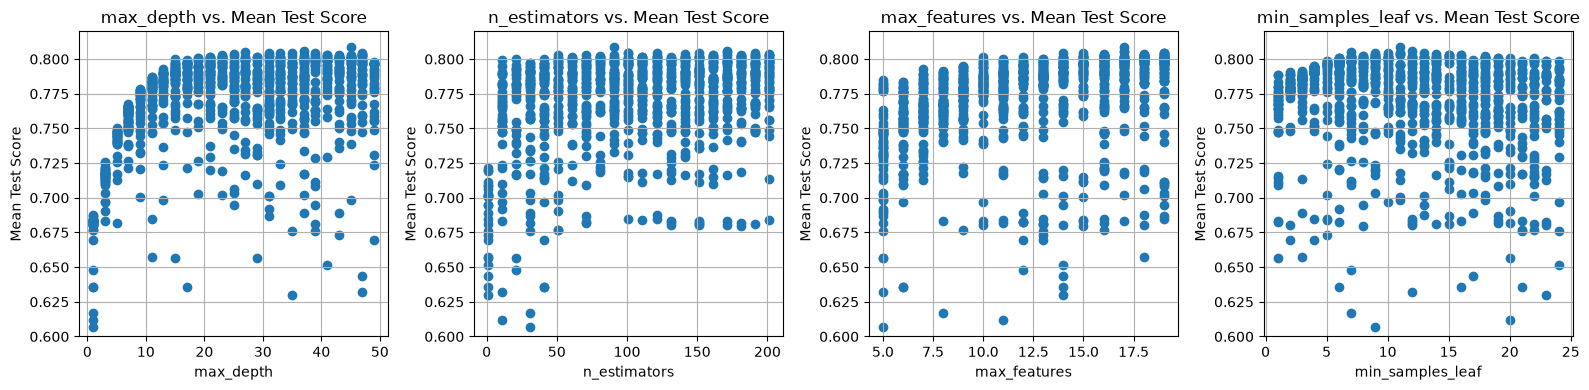

In [12]:
##### This cell is not meant to be executed####
hyperparameters_to_plot = ['param_max_depth', 'param_n_estimators', 'param_max_features', 'param_min_samples_leaf']
hyperparameter_labels = ['max_depth', 'n_estimators', 'max_features', 'min_samples_leaf']


fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

for i, hyperparam in enumerate(hyperparameters_to_plot):
    axes[i].scatter(results[hyperparam], results['mean_test_score'], marker='o')
    axes[i].set_xlabel(hyperparameter_labels[i])
    axes[i].set_ylabel('Mean Test Score')
    axes[i].set_title(f'{hyperparameter_labels[i]} vs. Mean Test Score')
    axes[i].grid(True)
    axes[i].set_ylim(0.6, 0.82)

plt.tight_layout()
plt.show()

**Q2.1**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.1** line above.


**Q2.2**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.2** line above.


#### Heatmaps
Q2.3: What do the following plots represent? 

Q2.4: What do the white spots (=empty spots) in the heatmaps mean?

Q2.5: How do those plots address the limitation of the previous visualizations? 

/home/benoit.hohl/miniconda3/envs/o2score/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/benoit.hohl/miniconda3/envs/o2score/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


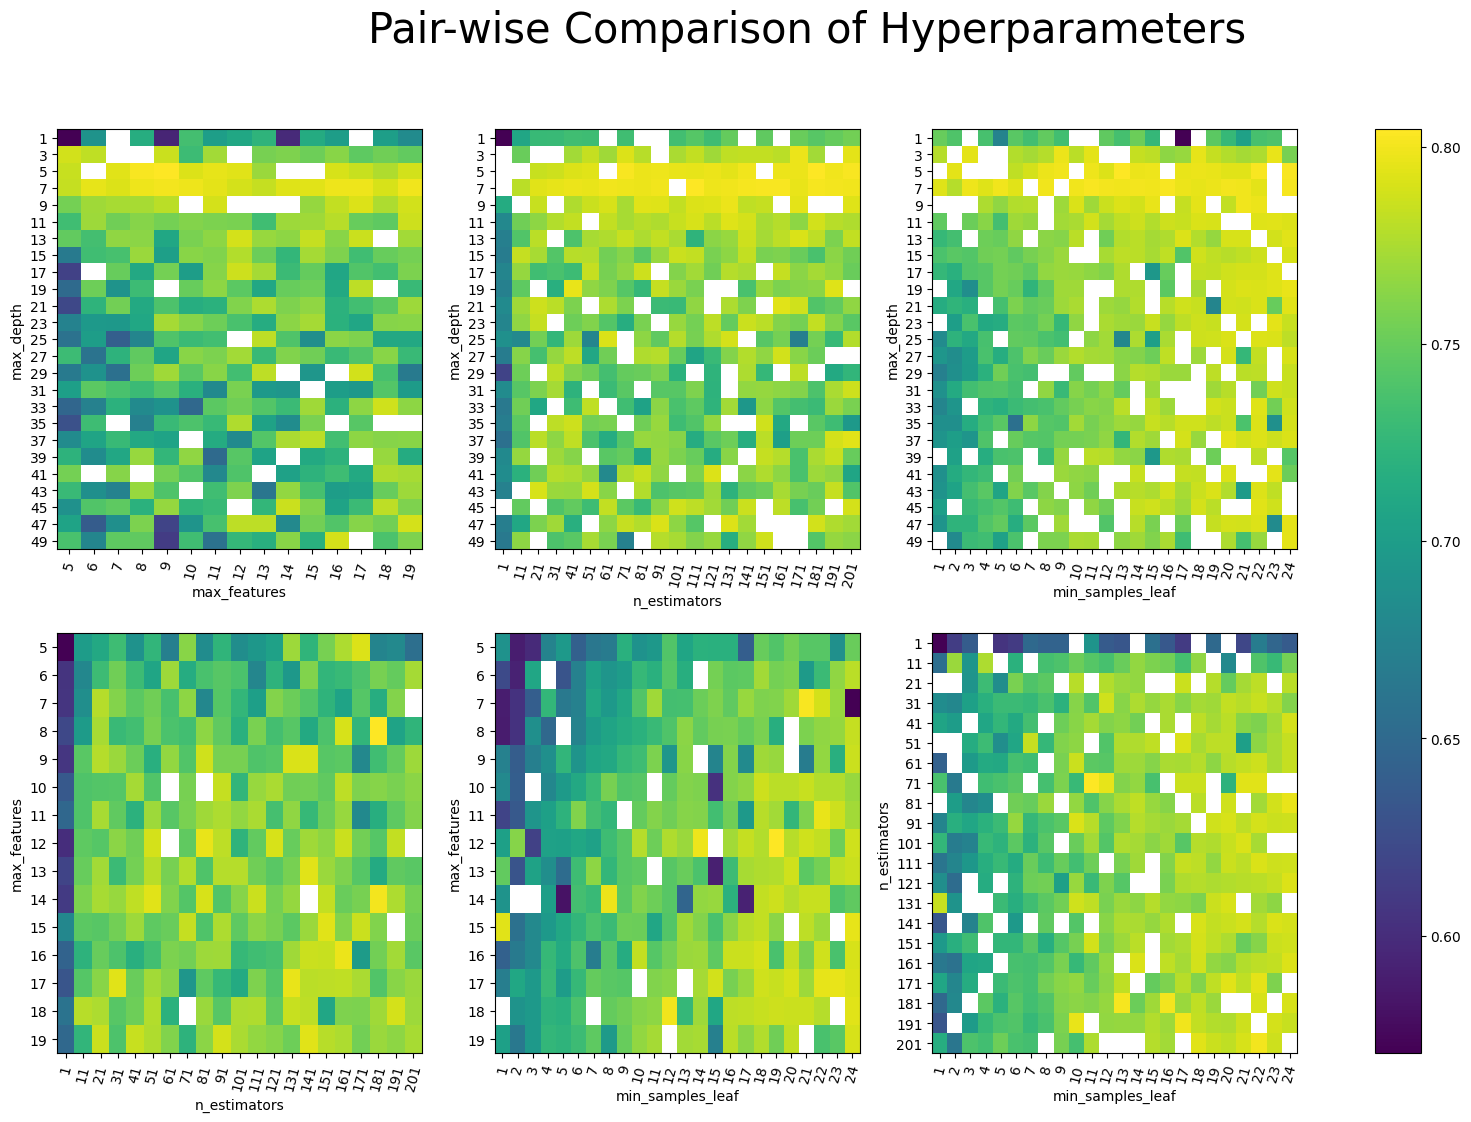

In [11]:
##### This cell is not meant to be executed####
# Convert masked arrays to regular arrays
max_depth_values = results['param_max_depth'].data
n_estimators_values = results['param_n_estimators'].data
max_features_values = results['param_max_features']
min_samples_leaf_values = results['param_min_samples_leaf']

hyperparameters = [max_depth_values,  max_features_values,n_estimators_values, min_samples_leaf_values]
hyperparameter_labels = ['max_depth', 'max_features','n_estimators', 'min_samples_leaf']

num_hyperparameters = len(hyperparameters)

# Calculate the number of rows required based on the number of hyperparameters and three columns
num_rows = (num_hyperparameters + 2) // 3  # Use integer division

fig, axes = plt.subplots(num_rows, 3, figsize=(20, 12))
fig.suptitle('Pair-wise Comparison of Hyperparameters',fontsize=30)

subplot_index = 0  # Initialize the subplot index

for i in range(num_hyperparameters):
    for j in range(i + 1, num_hyperparameters):  # Iterate over unique pairs only
        x_values = hyperparameters[i]
        y_values = hyperparameters[j]

        row_index = subplot_index // 3  # Calculate the row index based on the current subplot's position
        col_index = subplot_index % 3  # Calculate the column index based on the current subplot's position

        heatmap_data = np.zeros((len(np.unique(x_values)), len(np.unique(y_values))))

        for m, x_val in enumerate(np.unique(x_values)):
            for n, y_val in enumerate(np.unique(y_values)):
                mask = (x_values == x_val) & (y_values == y_val) #identifies data points where the hyperparameters match current evaluated combination 
                mean_score = np.mean(results['mean_test_score'][mask]) # average test score for a particular combination of x_val and y_val.
                heatmap_data[m, n] = mean_score

        im = axes[row_index, col_index].imshow(heatmap_data, cmap='viridis', aspect='auto', interpolation=None)

        axes[row_index, col_index].set_xticks(np.arange(len(np.unique(y_values))))
        axes[row_index, col_index].set_yticks(np.arange(len(np.unique(x_values))))
        axes[row_index, col_index].set_xticklabels(np.unique(y_values), rotation=75)
        axes[row_index, col_index].set_yticklabels(np.unique(x_values))

        axes[row_index, col_index].set_xlabel(hyperparameter_labels[j])
        axes[row_index, col_index].set_ylabel(hyperparameter_labels[i])

        subplot_index += 1  # Increment the subplot index

plt.colorbar(im, ax=axes.ravel().tolist())
plt.show()

**Q2.3**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.3** line above.


**Q2.4**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.4** line above.


**Q2.5**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.5** line above.


### Grid Search

Q2.6: What is grid search? Explain by giving real examples from this specific task.

Q2.7: Use the plots above to narrow the range of hyperparameters you want to explore. Which values did you choose to test for each parameter? Justify your choices.

Exercise 2.1: Once you know which values of hyperparameters you want to explore, complete the following code to perform a grid search on those values. Remember that the more values you choose to test, the longer the computational time required.

In [ ]:
#HYPERPARAMETERS FINETUNING WITH GRID SEARCH

#Define parameter grid
param_grid = ###TO COMPLETE###

#GRID SEARCH TO FIND BEST PARAMETERS
# Create random forest classifier
clf = RandomForestClassifier(random_state=0,class_weight='balanced')

# Create grid search object
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=4, n_jobs = -1, scoring='balanced_accuracy',verbose=2)

# Fit grid search to training data
grid_search = grid_search.fit(X_train,Y_train)

# Print best parameters
print('Best parameters:', grid_search.best_params_)

**Q2.6**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.6** line above.


**Q2.7**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.7** line above.


### FINAL MODEL TRAINING

It is now time to train your final RF model. Choose one final value for each of the hyperparameters based on your grid search.

Q.2.8: Which value did you choose for each hyperparameter? Why?

Exercise 2.2: Complete the code in order to choose one final value for each of the hyperparameters and train the model on the whole training set.

In [6]:
#FIT A SINGLE RANDOM FOREST GIVEN A SET OF HYPERPARAMETERS
hyperparameters = {
    ###TO CHANGE###
     'max_features': 1,
     'n_estimators': 1,
     'max_depth': 1,
     'min_samples_leaf': 1
}

# Create a Random Forest classifier with the specified parameters
rf_classifier = RandomForestClassifier(**hyperparameters, random_state=0,class_weight='balanced')#

# Fit the model on the training data
rf_classifier = rf_classifier.fit(X_train, Y_train)
print('final model trained')

final model trained


**Q2.8**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.8** line above.


### FINAL MODEL EVALUATION

Exercise: Write the code to evaluate the performance of your final model.

Q2.9: The test set should be used only at this stage, and it is theoretically important not to change the hyperparameters based on the performance on the test set. Why?

Q2.10: Comment your results. -> How well does the model generalize on unseen data? Is a random forest better than a single classification tree in this case? What is the main challenge of this dataset? ...

In [ ]:
#FINAL MODEL EVALUATION
...

**Q2.9**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.9** line above.


**Q2.10**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.10** line above.


### FEATURES IMPORTANCE

The following graph represents the importance of each feature for the classification.

Q2.11: How is this importance calculate?

Q2.12: What can you conclude from this graph?

In [ ]:
# Calculate feature importances and SEM
importances = rf_classifier.feature_importances_
n_trees = len(rf_classifier.estimators_)
std = np.std([tree.feature_importances_ for tree in rf_classifier.estimators_], axis=0)
sem = std / np.sqrt(n_trees)

# Plot features importance
forest_importances = pd.Series(importances)
fig, ax = plt.subplots(figsize=(25, 15))
plt.xticks(rotation=90, fontsize=20)
forest_importances.plot.bar(ax=ax, yerr=sem)  # Use SEM for error bars
ax.set_title("Feature importances using MDI", fontsize=45)
ax.set_ylabel("Mean decrease in impurity", fontsize=20)
fig.tight_layout()

**Q2.11**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.11** line above.


**Q2.12**

> **ANSWER HERE.** This cell goes into the PDF report. Delete this text and write your answer in its place, as many lines or paragraphs as you need. Keep the **Q2.12** line above.
